In [ ]:
# importo las librerías necesarias

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
# cargo el dataset
farmacos = pd.read_csv("drugLibTrain_raw.csv", sep=",")
farmacos.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [3]:
farmacos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   urlDrugName        3107 non-null   str  
 1   rating             3107 non-null   int64
 2   effectiveness      3107 non-null   str  
 3   sideEffects        3107 non-null   str  
 4   condition          3106 non-null   str  
 5   benefitsReview     3089 non-null   str  
 6   sideEffectsReview  3032 non-null   str  
 7   commentsReview     3095 non-null   str  
dtypes: int64(1), str(7)
memory usage: 194.3 KB


In [4]:
farmacos.describe()

,rating
count,3107.000000
mean,7.006115
std,2.937582
min,1.000000
25%,5.000000
50%,8.000000
75%,9.000000
max,10.000000


#### Selección de columnas

In [5]:
# Columnas numéricas
col_num = farmacos.select_dtypes(include="number").columns.tolist() #

# Columnas categóricas con menos de 10 categorías únicas
col_cat = [c for c in farmacos.select_dtypes(include="object").columns # itero sobre las columnas categóricas
           if farmacos[c].nunique() < 10] # si el número de categorías únicas es menor a 10, la añado a la lista

print("Numéricas:", col_num) # imprimo las columnas numéricas
print("Categóricas válidas:", col_cat) # imprimo las columnas categóricas válidas

Numéricas: ['rating']
Categóricas válidas: ['effectiveness', 'sideEffects']


In [6]:
farmacos_def = farmacos[col_num + col_cat].copy() # creo un nuevo dataframe con las columnas numéricas y las categóricas válidas
farmacos_def.head()

,rating,effectiveness,sideEffects
0,4,Highly Effective,Mild Side Effects
1,1,Highly Effective,Severe Side Effects
2,10,Highly Effective,No Side Effects
3,3,Marginally Effective,Mild Side Effects
4,2,Marginally Effective,Severe Side Effects


#### Transformación de variables categóricas

In [ ]:
farmacos_trans = pd.get_dummies(farmacos_def, columns=col_cat) # transformo las columnas categóricas añadiendo
                                                               # más columnas con valores binarios (0 o 1) para cada categoría

print("Shape tras dummies:", farmacos_trans.shape) # imprimo la nueva forma del dataframe tras aplicar get_dummies
farmacos_trans.head()

Shape tras dummies: (3107, 11)


,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,4,False,True,False,False,False,False,True,False,False,False
1,1,False,True,False,False,False,False,False,False,False,True
2,10,False,True,False,False,False,False,False,False,True,False
3,3,False,False,False,True,False,False,True,False,False,False
4,2,False,False,False,True,False,False,False,False,False,True


#### Evaluación de la mejor K con Silhouette

In [8]:
silhouette_scores = {} # creo un diccionario para almacenar los scores de silhouette para cada K

for k in range(2, 9): # itero sobre los valores de K desde 2 hasta 8 (no tiene sentido probar con K=1 porque no habría clusters)
    km = KMeans(n_clusters=k, random_state=11, n_init=10) # creo el modelo de KMeans con el número de clusters igual a K, una semilla y n_init=10
    labels = km.fit_predict(farmacos_trans) # ajusto el modelo a los datos y obtengo las etiquetas de cluster para cada muestra
    score = silhouette_score(farmacos_trans, labels) # calculo el score de silhouette para las etiquetas obtenidas
    silhouette_scores[k] = round(score, 4) # almaceno el score de silhouette en el diccionario redondeado a 4 decimales
    print(f"K={k} → silhouette={score:.4f}") # imprimo el valor de K y su correspondiente score de silhouette formateado a 4 decimales

best_k = max(silhouette_scores, key=silhouette_scores.get) # obtengo el valor de K que tiene el mayor score de silhouette utilizando la función max con el diccionario de scores
print(f"Mejor K: {best_k} (silhouette={silhouette_scores[best_k]})") # imprimo el mejor valor de K y su correspondiente score de silhouette utilizando el diccionario de scores

K=2 → silhouette=0.6055
K=3 → silhouette=0.4382
K=4 → silhouette=0.3971
K=5 → silhouette=0.3563
K=6 → silhouette=0.3800
K=7 → silhouette=0.3741
K=8 → silhouette=0.4023
Mejor K: 2 (silhouette=0.6055)


#### Genera el K-Means final

In [10]:
modelo_km_final = KMeans(n_clusters=best_k, random_state=11, n_init=10) # creo el modelo de KMeans final utilizando el mejor valor de K encontrado, la misma semilla y n_init=10
farmacos_def["cluster"] = modelo_km_final.fit_predict(farmacos_trans) # ajusto el modelo final a los datos transformados y asigno las etiquetas de cluster obtenidas a una nueva columna "cluster" en el dataframe original con las columnas seleccionadas

print("Distribución de clusters:") 
print(farmacos_def["cluster"].value_counts()) # imprimo la distribución de muestras en cada cluster utilizando value_counts() sobre la columna "cluster" del dataframe original con las columnas seleccionadas

Distribución de clusters:
cluster
0    2287
1     820
Name: count, dtype: int64


#### Comprueba los resultados

In [12]:
# agrupo por cluster y calculo la media de las columnas numéricas para cada cluster
farmacos_def.groupby("cluster").mean(numeric_only=True)

,rating
cluster,
0,8.56843
1,2.64878


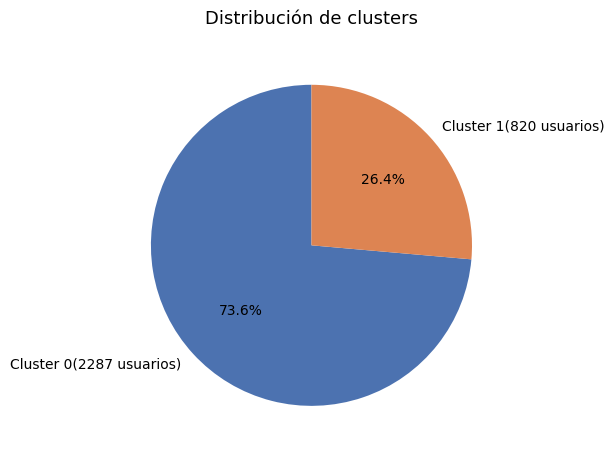

In [16]:
conteo = farmacos_def["cluster"].value_counts().sort_index() # cuento el número de muestras en cada cluster utilizando value_counts() sobre la columna "cluster" y ordeno por índice para que los clusters estén en orden numérico
etiquetas = [f"Cluster {i}({v} usuarios)" for i, v in conteo.items()] # creo una lista de etiquetas para cada cluster con su número de usuarios utilizando una comprensión de listas que itera sobre los items del conteo de clusters

# gráfico de tarta para visualizar la distribución de clusters
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo, labels=etiquetas, autopct="%1.1f%%", 
       startangle=90, colors=["#4C72B0", "#DD8452"])
ax.set_title(f"Distribución de clusters", fontsize=13, pad=15)
plt.tight_layout();